In [1]:
import os
import pickle

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from pycisTopic.fragments import read_fragments_to_polars_df, read_bed_to_polars_df
from pycisTopic.qc import compute_qc_stats

%matplotlib inline

/home/jovyan/pycisTopic/src/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
# Paths are anchored to this notebook's own location, so this works both
# inside the Docker container and on a native server, regardless of where
# the repository is cloned.
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))

SAMPLE = "8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller"

# PUMATAC output (produced by notebooks_PUMATAC/2_running_nextflow_pipeline.ipynb)
FRAGMENTS_PATH = os.path.join(
    NOTEBOOK_DIR, "notebooks_PUMATAC", "out", "data", "fragments",
    f"{SAMPLE}.fragments.tsv.gz",
)

# Verified local TSS annotation (see resources/README.md)
ANNOTATION_TSV = os.path.join(REPO_ROOT, "resources", "mm10_annotation.tsv")

# ENCODE SCREEN candidate regulatory regions, used to compute FRIP
REGIONS_BED = "/home/jovyan/work/PUMATAC_dependencies/regions/V2.mm10-rDHS-Unfiltered.blacklisted.bed"

# Output directory for QC results
QC_OUT = os.path.join(REPO_ROOT, "results", "qc")
os.makedirs(QC_OUT, exist_ok=True)

for name, path in [
    ("fragments", FRAGMENTS_PATH),
    ("annotation", ANNOTATION_TSV),
    ("regions", REGIONS_BED),
]:
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"{status:8s} {name:12s} {path}")

print(f"\nQC output directory: {QC_OUT}")

OK       fragments    /home/jovyan/work/repo/notebooks/notebooks_PUMATAC/out/data/fragments/8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller.fragments.tsv.gz
OK       annotation   /home/jovyan/work/repo/resources/mm10_annotation.tsv
OK       regions      /home/jovyan/work/PUMATAC_dependencies/regions/V2.mm10-rDHS-Unfiltered.blacklisted.bed

QC output directory: /home/jovyan/work/repo/results/qc


In [3]:
# The local annotation is in the format produced by the older pypumatac
# helper (columns: Chromosome, Start, Strand, Gene, Transcript_type, with
# UCSC-style chromosome names and strand encoded as 1 / -1).
#
# The current pycisTopic API expects a TSS annotation in BED format:
#   Chromosome, Start (0-based), End, Gene, Score, Strand, Transcript_type
# with strand as + / - .
#
# Chromosome naming is left as-is (chr-prefixed): the fragments produced by
# PUMATAC use UCSC-style names for the main chromosomes (chr1, chr2, ...,
# chrX, chrY, chrM), verified directly on the data in the cell below.

annotation = pd.read_csv(ANNOTATION_TSV, sep="\t", index_col=0)
print("Original annotation:")
print(annotation.head(3))
print(f"Rows: {len(annotation)}")

tss_bed = pd.DataFrame({
    "Chromosome": annotation["Chromosome"],
    "Start": annotation["Start"].astype(int),
    "End": annotation["Start"].astype(int) + 1,
    "Gene": annotation["Gene"],
    "Score": 0,
    "Strand": annotation["Strand"].map({1: "+", -1: "-"}),
    "Transcript_type": annotation["Transcript_type"],
})

print("\nConverted to BED format:")
print(tss_bed.head(3))
print(f"Rows: {len(tss_bed)}")
print(f"Strand values: {tss_bed['Strand'].unique()}")
print(f"Any NaN in Strand: {tss_bed['Strand'].isna().any()}")

Original annotation:
    Chromosome      Start  Strand       Gene Transcript_type
58        chr2  154551776       1     Actl10  protein_coding
624       chrX   31117674       1  Btbd35f29  protein_coding
946       chr7   84915781       1    Olfr290  protein_coding
Rows: 54721

Converted to BED format:
    Chromosome      Start        End       Gene  Score Strand Transcript_type
58        chr2  154551776  154551777     Actl10      0      +  protein_coding
624       chrX   31117674   31117675  Btbd35f29      0      +  protein_coding
946       chr7   84915781   84915782    Olfr290      0      +  protein_coding
Rows: 54721
Strand values: ['+' '-']
Any NaN in Strand: False


In [4]:
# Write the converted annotation to a BED file and load it through
# pycisTopic's own reader, so the resulting DataFrame has exactly the
# schema the QC functions expect.
tss_bed_path = os.path.join(QC_OUT, "mm10_tss_annotation.bed")

with open(tss_bed_path, "w") as f:
    f.write("# Chromosome\tStart\tEnd\tGene\tScore\tStrand\tTranscript_type\n")
    tss_bed.to_csv(f, sep="\t", header=False, index=False)

print(f"Written: {tss_bed_path}")

from pycisTopic.gene_annotation import read_tss_annotation_from_bed

tss_annotation_bed_df_pl = read_tss_annotation_from_bed(
    tss_annotation_bed_filename=tss_bed_path
)

print(f"\nLoaded TSS annotation: {tss_annotation_bed_df_pl.shape}")
print(tss_annotation_bed_df_pl.head(3))

Written: /home/jovyan/work/repo/results/qc/mm10_tss_annotation.bed

Loaded TSS annotation: (54721, 7)
shape: (3, 7)
┌────────────┬───────────┬───────────┬───────────┬───────┬────────┬─────────────────┐
│ Chromosome ┆ Start     ┆ End       ┆ Gene      ┆ Score ┆ Strand ┆ Transcript_type │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---   ┆ ---    ┆ ---             │
│ cat        ┆ i32       ┆ i32       ┆ str       ┆ i64   ┆ str    ┆ str             │
╞════════════╪═══════════╪═══════════╪═══════════╪═══════╪════════╪═════════════════╡
│ chr2       ┆ 154551776 ┆ 154551777 ┆ Actl10    ┆ 0     ┆ +      ┆ protein_coding  │
│ chrX       ┆ 31117674  ┆ 31117675  ┆ Btbd35f29 ┆ 0     ┆ +      ┆ protein_coding  │
│ chr7       ┆ 84915781  ┆ 84915782  ┆ Olfr290   ┆ 0     ┆ +      ┆ protein_coding  │
└────────────┴───────────┴───────────┴───────────┴───────┴────────┴─────────────────┘


In [5]:
# Load the fragments produced by PUMATAC.
# Note: PUMATAC writes barcodes without a "-1" suffix and without a sample
# suffix, so both cleanup steps are disabled to keep them unchanged.
print("Loading fragments (this takes a few minutes)...")
fragments_df_pl = read_fragments_to_polars_df(
    fragments_bed_filename=FRAGMENTS_PATH,
    engine="pyarrow",
    cb_end_to_remove=None,
    cb_sample_separator=None,
)
print(f"Fragments loaded: {fragments_df_pl.shape}")
print(fragments_df_pl.head(3))

# Load ENCODE SCREEN candidate regulatory regions (used to compute FRIP).
# Both this file and the fragments use UCSC-style chromosome names, so no
# renaming is needed - but this is verified explicitly below rather than
# assumed, since chromosome naming mismatches silently produce empty
# results instead of errors.
print("\nLoading regions...")
regions_df_pl = read_bed_to_polars_df(
    bed_filename=REGIONS_BED,
    min_column_count=3,
)
print(f"Regions loaded: {regions_df_pl.shape}")
print(regions_df_pl.head(3))

Loading fragments (this takes a few minutes)...
Fragments loaded: (240909947, 5)
shape: (3, 5)
┌────────────┬───────┬─────┬──────────────────┬───────┐
│ Chromosome ┆ Start ┆ End ┆ Name             ┆ Score │
│ ---        ┆ ---   ┆ --- ┆ ---              ┆ ---   │
│ cat        ┆ i32   ┆ i32 ┆ cat              ┆ i32   │
╞════════════╪═══════╪═════╪══════════════════╪═══════╡
│ GL456210.1 ┆ 771   ┆ 983 ┆ GCTATACGATTAGAAG ┆ 1     │
│ GL456210.1 ┆ 777   ┆ 994 ┆ TACCTTCCTTTACGAC ┆ 1     │
│ GL456210.1 ┆ 782   ┆ 955 ┆ CTGTGCACTTTCGCCT ┆ 1     │
└────────────┴───────┴─────┴──────────────────┴───────┘

Loading regions...
Regions loaded: (1212823, 10)
shape: (3, 10)
┌────────────┬─────────┬─────────┬────────────┬───┬────────────┬──────────┬───────────┬────────────┐
│ Chromosome ┆ Start   ┆ End     ┆ Name       ┆ … ┆ ThickStart ┆ ThickEnd ┆ ItemRGB   ┆ BlockCount │
│ ---        ┆ ---     ┆ ---     ┆ ---        ┆   ┆ ---        ┆ ---      ┆ ---       ┆ ---        │
│ cat        ┆ i32     ┆ i32     

In [6]:
# Chromosome naming sanity check.
# A mismatch here does not raise an error: it silently produces an empty
# TSS matrix, which only fails much later with an obscure message
# ("unable to transpose an empty DataFrame"). Checking explicitly is cheap
# and makes the failure mode obvious.
frag_chroms = set(fragments_df_pl["Chromosome"].cast(pl.Utf8).unique().to_list())
tss_chroms = set(tss_annotation_bed_df_pl["Chromosome"].cast(pl.Utf8).unique().to_list())
reg_chroms = set(regions_df_pl["Chromosome"].cast(pl.Utf8).unique().to_list())

print(f"Fragments:  {len(frag_chroms)} chromosomes, e.g. {sorted(frag_chroms)[-5:]}")
print(f"TSS:        {len(tss_chroms)} chromosomes, e.g. {sorted(tss_chroms)[-5:]}")
print(f"Regions:    {len(reg_chroms)} chromosomes, e.g. {sorted(reg_chroms)[-5:]}")
print()
print(f"TSS     shared with fragments: {len(frag_chroms & tss_chroms)}")
print(f"Regions shared with fragments: {len(frag_chroms & reg_chroms)}")

assert len(frag_chroms & tss_chroms) > 0, "No shared chromosomes between fragments and TSS annotation"
assert len(frag_chroms & reg_chroms) > 0, "No shared chromosomes between fragments and regions"
print("\nChromosome naming is consistent.")

Fragments:  56 chromosomes, e.g. ['chr8', 'chr9', 'chrM', 'chrX', 'chrY']
TSS:        21 chromosomes, e.g. ['chr7', 'chr8', 'chr9', 'chrX', 'chrY']
Regions:    21 chromosomes, e.g. ['chr7', 'chr8', 'chr9', 'chrX', 'chrY']

TSS     shared with fragments: 21
Regions shared with fragments: 21

Chromosome naming is consistent.


In [7]:
frag_chroms = set(fragments_df_pl["Chromosome"].unique().to_list())
tss_chroms = set(tss_annotation_bed_df_pl["Chromosome"].unique().to_list())

print(f"Fragments: {len(frag_chroms)} chromosomes")
print(sorted(frag_chroms)[:10])
print()
print(f"TSS annotation: {len(tss_chroms)} chromosomes")
print(sorted(tss_chroms)[:10])
print()
print(f"In common: {len(frag_chroms & tss_chroms)}")
print(sorted(frag_chroms & tss_chroms)[:10])

Fragments: 56 chromosomes
['GL456210.1', 'GL456211.1', 'GL456212.1', 'GL456216.1', 'GL456221.1', 'GL456233.1', 'GL456239.1', 'GL456354.1', 'GL456359.1', 'GL456360.1']

TSS annotation: 21 chromosomes
['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18']

In common: 21
['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18']


In [8]:
frag_chroms = set(fragments_df_pl["Chromosome"].cast(pl.Utf8).unique().to_list())
tss_chroms = set(tss_annotation_bed_df_pl["Chromosome"].cast(pl.Utf8).unique().to_list())

print(f"Fragments ({len(frag_chroms)}): {sorted(frag_chroms)}")
print()
print(f"TSS ({len(tss_chroms)}): {sorted(tss_chroms)}")
print()
print(f"In common ({len(frag_chroms & tss_chroms)}): {sorted(frag_chroms & tss_chroms)}")

Fragments (56): ['GL456210.1', 'GL456211.1', 'GL456212.1', 'GL456216.1', 'GL456221.1', 'GL456233.1', 'GL456239.1', 'GL456354.1', 'GL456359.1', 'GL456360.1', 'GL456366.1', 'GL456367.1', 'GL456368.1', 'GL456370.1', 'GL456372.1', 'GL456378.1', 'GL456379.1', 'GL456381.1', 'GL456382.1', 'GL456383.1', 'GL456385.1', 'GL456387.1', 'GL456389.1', 'GL456390.1', 'GL456392.1', 'GL456393.1', 'GL456394.1', 'GL456396.1', 'JH584292.1', 'JH584295.1', 'JH584296.1', 'JH584297.1', 'JH584299.1', 'JH584304.1', 'chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrM', 'chrX', 'chrY']

TSS (21): ['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX', 'chrY']

In common (21): ['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr3',

In [9]:
# Compute QC statistics. Returns four DataFrames:
#   - fragments_stats_per_cb_df_pl: per-barcode stats (fragment counts,
#     duplication rate, FRIP, TSS enrichment, ...)
#   - insert_size_dist_df_pl: insert size distribution for the sample
#   - tss_norm_matrix_sample: aggregated TSS profile for the sample
#   - tss_norm_matrix_per_cb: per-barcode TSS enrichment matrix
print("Computing QC stats (this is the slow step)...")

(
    fragments_stats_per_cb_df_pl,
    insert_size_dist_df_pl,
    tss_norm_matrix_sample,
    tss_norm_matrix_per_cb,
) = compute_qc_stats(
    fragments_df_pl=fragments_df_pl,
    regions_df_pl=regions_df_pl,
    tss_annotation=tss_annotation_bed_df_pl,
    tss_flank_window=2000,
    tss_smoothing_rolling_window=10,
    tss_minimum_signal_window=100,
    tss_window=50,
    tss_min_norm=0.2,
    use_genomic_ranges=True,
    min_fragments_per_cb=10,
    collapse_duplicates=True,
    no_threads=8,
)

print("Done.")
print(f"\nPer-barcode stats: {fragments_stats_per_cb_df_pl.shape}")
print(fragments_stats_per_cb_df_pl.head(3))
print(f"\nColumns: {fragments_stats_per_cb_df_pl.columns}")

Computing QC stats (this is the slow step)...
Done.

Per-barcode stats: (167606, 18)
shape: (3, 18)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ CB        ┆ barcode_r ┆ total_fra ┆ log10_tot ┆ … ┆ tss_enric ┆ pdf_value ┆ pdf_value ┆ pdf_valu │
│ ---       ┆ ank       ┆ gments_co ┆ al_fragme ┆   ┆ hment     ┆ s_for_tss ┆ s_for_fra ┆ es_for_d │
│ cat       ┆ ---       ┆ unt       ┆ nts_count ┆   ┆ ---       ┆ _enrichme ┆ ction_of_ ┆ uplicati │
│           ┆ u32       ┆ ---       ┆ ---       ┆   ┆ f64       ┆ nt        ┆ fra…      ┆ on_rat…  │
│           ┆           ┆ u32       ┆ f64       ┆   ┆           ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ TCGCGTACT ┆ 1         ┆ 149895    ┆ 5.17579   ┆ … ┆ 7.949313  ┆ 0.000045  ┆ 0.00083   ┆ 0.

In [10]:
from pycisTopic.qc import get_otsu_threshold

# Otsu thresholding on unique fragment count and TSS enrichment, the same
# criteria used in the first reproduction of this analysis.
(
    unique_fragments_threshold,
    tss_enrichment_threshold,
    fragments_stats_per_cb_for_otsu_threshold_df_pl,
) = get_otsu_threshold(
    fragments_stats_per_cb_df_pl=fragments_stats_per_cb_df_pl,
    min_otsu_fragments=100,
    min_otsu_tss=1.0,
)

print(f"Otsu threshold - unique fragments: {unique_fragments_threshold}")
print(f"Otsu threshold - TSS enrichment:   {tss_enrichment_threshold}")
print(f"\nCells passing filter: {fragments_stats_per_cb_for_otsu_threshold_df_pl.shape[0]}")

Otsu threshold - unique fragments: 1610.0249752939658
Otsu threshold - TSS enrichment:   11.249070963221792

Cells passing filter: 6111


In [13]:
# Summary of QC metrics for the cells passing the Otsu filter.
# Note the distinction between the two "unique fragments" columns:
#   - unique_fragments_count: all unique fragments per cell
#   - unique_fragments_in_peaks_count: only those falling in the candidate
#     regulatory regions (this is the metric typically reported in QC plots)
selected = fragments_stats_per_cb_for_otsu_threshold_df_pl

print("QC summary for cells passing the Otsu filter")
print("-" * 50)
print(f"Cells passing filter:              {selected.shape[0]}")
print(f"Otsu threshold, unique fragments:  {unique_fragments_threshold:.0f}")
print(f"Otsu threshold, TSS enrichment:    {tss_enrichment_threshold:.2f}")
print("-" * 50)
print(f"Median unique fragments:           {selected['unique_fragments_count'].median():.0f}")
print(f"Median unique fragments in peaks:  {selected['unique_fragments_in_peaks_count'].median():.0f}")
print(f"Median TSS enrichment:             {selected['tss_enrichment'].median():.2f}")
print(f"Median FRIP:                       {selected['fraction_of_fragments_in_peaks'].median():.2f}")
print(f"Median duplication ratio:          {selected['duplication_ratio'].median():.2f}")

QC summary for cells passing the Otsu filter
--------------------------------------------------
Cells passing filter:              6111
Otsu threshold, unique fragments:  1610
Otsu threshold, TSS enrichment:    11.25
--------------------------------------------------
Median unique fragments:           25213
Median unique fragments in peaks:  14550
Median TSS enrichment:             17.55
Median FRIP:                       0.58
Median duplication ratio:          0.35


In [14]:
# Save QC results for downstream analysis.
# Following the lesson from the first reproduction: save immediately after
# an expensive computation, in the same cell, so a kernel restart doesn't
# throw away hours of work.

# Barcodes passing the Otsu filter (needed to build the cisTopic object)
bc_passing_filters = selected["CB"].cast(pl.Utf8).to_list()
with open(os.path.join(QC_OUT, f"{SAMPLE}__bc_passing_filters_otsu.pkl"), "wb") as f:
    pickle.dump(bc_passing_filters, f, protocol=pickle.HIGHEST_PROTOCOL)

# Full per-barcode statistics (all barcodes, not only the selected ones)
fragments_stats_per_cb_df_pl.write_parquet(
    os.path.join(QC_OUT, f"{SAMPLE}__fragments_stats_per_cb.parquet")
)

# Insert size distribution and TSS profiles
insert_size_dist_df_pl.write_parquet(
    os.path.join(QC_OUT, f"{SAMPLE}__insert_size_dist.parquet")
)
tss_norm_matrix_sample.write_parquet(
    os.path.join(QC_OUT, f"{SAMPLE}__tss_norm_matrix_sample.parquet")
)

# Otsu thresholds, for reference and reproducibility
thresholds = {
    "unique_fragments_threshold": float(unique_fragments_threshold),
    "tss_enrichment_threshold": float(tss_enrichment_threshold),
    "n_cells_passing": int(selected.shape[0]),
}
with open(os.path.join(QC_OUT, f"{SAMPLE}__otsu_thresholds.pkl"), "wb") as f:
    pickle.dump(thresholds, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved to {QC_OUT}:")
for fname in sorted(os.listdir(QC_OUT)):
    size_mb = os.path.getsize(os.path.join(QC_OUT, fname)) / 1e6
    print(f"  {fname:60s} {size_mb:8.2f} MB")

Saved to /home/jovyan/work/repo/results/qc:
  8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller__bc_passing_filters_otsu.pkl     0.12 MB
  8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller__fragments_stats_per_cb.parquet     6.74 MB
  8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller__insert_size_dist.parquet     0.01 MB
  8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller__otsu_thresholds.pkl     0.00 MB
  8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller__tss_norm_matrix_sample.parquet     0.04 MB
  mm10_tss_annotation.bed                                          2.71 MB


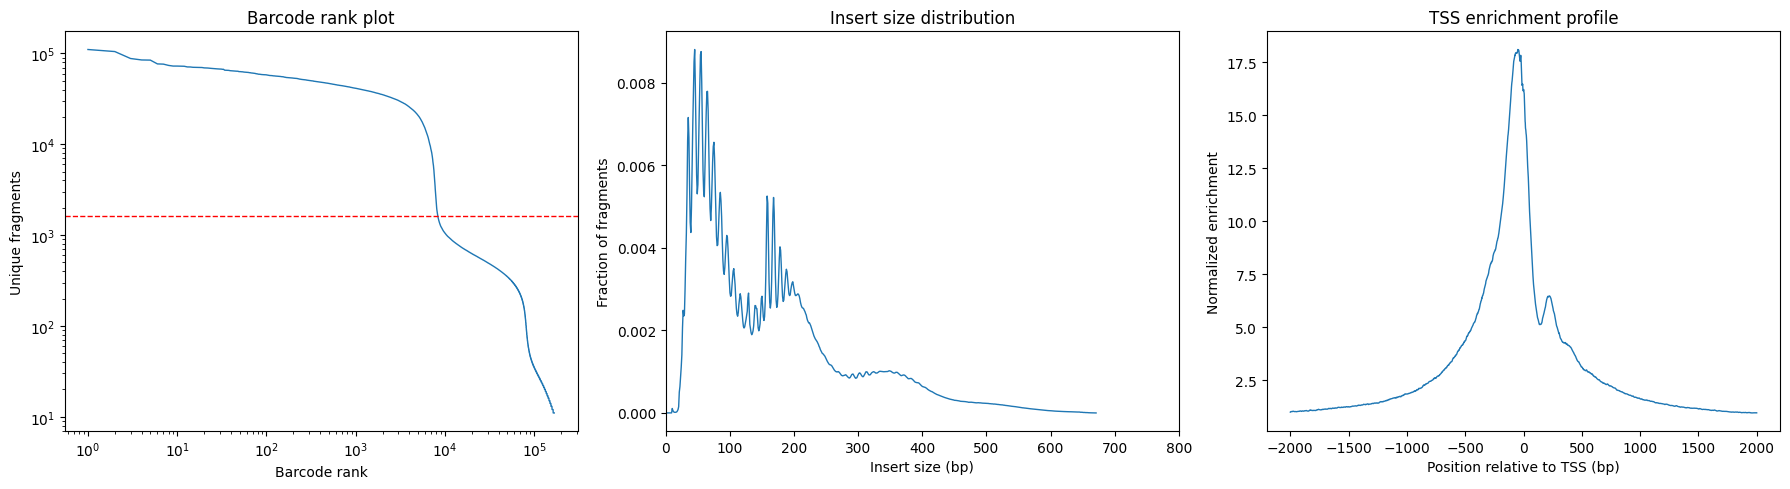

In [16]:
stats = fragments_stats_per_cb_df_pl

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Barcode rank plot: unique fragments per barcode, ranked
ax = axes[0]
ax.plot(
    stats["barcode_rank"].to_numpy(),
    stats["unique_fragments_count"].to_numpy(),
    linewidth=1,
)
ax.axhline(unique_fragments_threshold, color="red", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Barcode rank")
ax.set_ylabel("Unique fragments")
ax.set_title("Barcode rank plot")

# Insert size distribution
ax = axes[1]
ax.plot(
    insert_size_dist_df_pl["insert_size"].to_numpy(),
    insert_size_dist_df_pl["fragments_ratio"].to_numpy(),
    linewidth=1,
)
ax.set_xlim(0, 800)
ax.set_xlabel("Insert size (bp)")
ax.set_ylabel("Fraction of fragments")
ax.set_title("Insert size distribution")

# Aggregated TSS profile
ax = axes[2]
ax.plot(
    tss_norm_matrix_sample["position_from_tss"].to_numpy(),
    tss_norm_matrix_sample["normalized_tss_enrichment"].to_numpy(),
    linewidth=1,
)
ax.set_xlabel("Position relative to TSS (bp)")
ax.set_ylabel("Normalized enrichment")
ax.set_title("TSS enrichment profile")

plt.tight_layout()
plt.savefig(os.path.join(QC_OUT, f"{SAMPLE}__qc_profiles.png"), dpi=150, bbox_inches="tight")
plt.show()

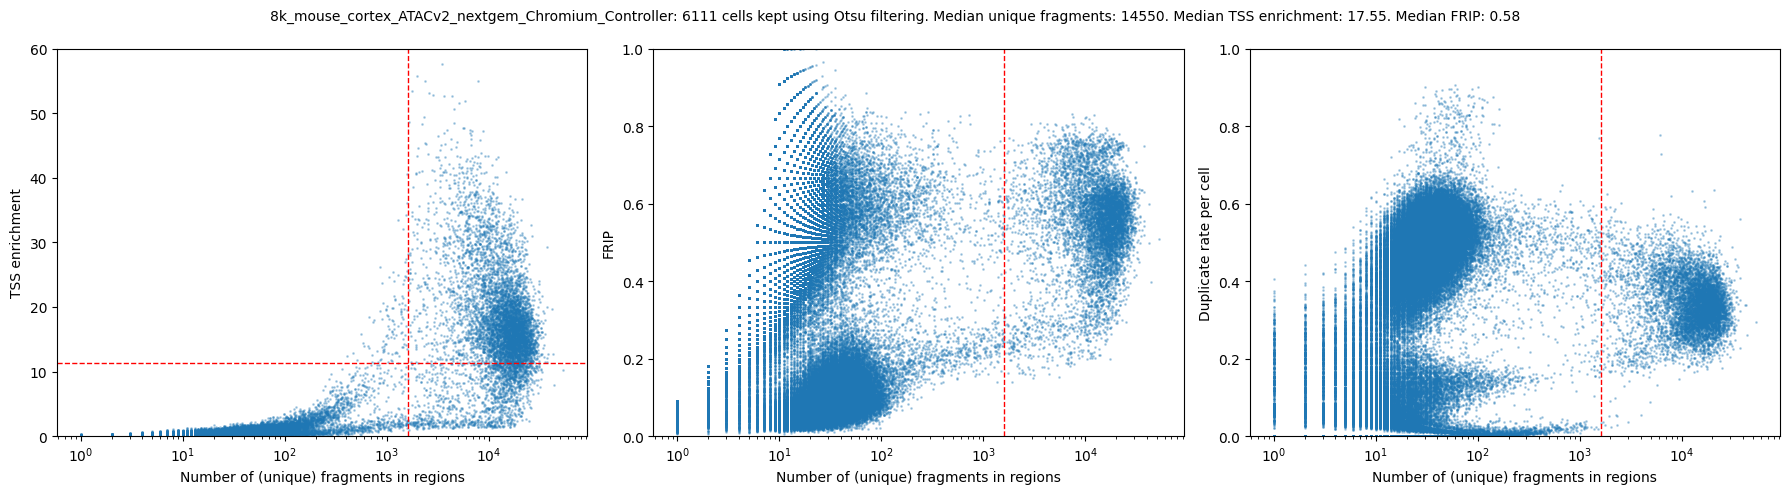

In [17]:
stats = fragments_stats_per_cb_df_pl

x = stats["unique_fragments_in_peaks_count"].to_numpy()

panels = [
    ("tss_enrichment", "TSS enrichment", tss_enrichment_threshold),
    ("fraction_of_fragments_in_peaks", "FRIP", None),
    ("duplication_ratio", "Duplicate rate per cell", None),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (column, label, hline) in zip(axes, panels):
    ax.scatter(x, stats[column].to_numpy(), s=1, alpha=0.3, rasterized=True)
    ax.set_xscale("log")
    ax.set_xlabel("Number of (unique) fragments in regions")
    ax.set_ylabel(label)
    ax.axvline(unique_fragments_threshold, color="red", linestyle="--", linewidth=1)
    if hline is not None:
        ax.axhline(hline, color="red", linestyle="--", linewidth=1)

axes[0].set_ylim(0, 60)
axes[1].set_ylim(0, 1)
axes[2].set_ylim(0, 1)

fig.suptitle(
    f"{SAMPLE}: {selected.shape[0]} cells kept using Otsu filtering. "
    f"Median unique fragments: {selected['unique_fragments_in_peaks_count'].median():.0f}. "
    f"Median TSS enrichment: {selected['tss_enrichment'].median():.2f}. "
    f"Median FRIP: {selected['fraction_of_fragments_in_peaks'].median():.2f}",
    fontsize=10,
)

plt.tight_layout()
plt.savefig(os.path.join(QC_OUT, f"{SAMPLE}__qc_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()